# TruthLens: AI Generated News Detection

This notebook trains multiple machine learning and deep learning models to detect misinformation in AI-generated news articles.

## Models Implemented
1. Logistic Regression (Baseline)
2. Convolutional Neural Network (CNN)
3. Bidirectional LSTM (BiLSTM)

## Dataset
AI News Dataset containing news articles with misinformation labels.

In [6]:
!pip install pandas scikit-learn tensorflow nltk


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\hariv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

## Load AI News Dataset

In [75]:
df = pd.read_csv("../data/ai_news/ai_news_dataset.csv")
df.head()

,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P0001,Reddit,2024-03-06 10:01:00,2024-03-06,10:01:00,March,Wednesday,USA,New York,...,-0.223,0.271,GPT-like,0.829,0.357,TRUE,4,0.543,3899,1
1,2,P0002,Reddit,2025-08-07 18:30:00,2025-08-07,18:30:00,August,Thursday,Germany,Berlin,...,-0.718,0.802,GPT-like,0.075,0.987,FALSE,3,0.199,7651,0
2,3,P0003,Telegram,2024-12-13 03:15:00,2024-12-13,03:15:00,December,Friday,USA,New York,...,-0.989,0.815,GPT-like,0.707,0.729,PARTLY,0,0.074,7260,0
3,4,P0004,Twitter,2024-04-05 07:10:00,2024-04-05,07:10:00,April,Friday,USA,Chicago,...,-0.283,0.116,human,0.863,0.623,FALSE,2,0.064,7454,1
4,5,P0005,Telegram,2024-06-07 06:18:00,2024-06-07,06:18:00,June,Friday,Germany,Hamburg,...,-0.378,0.325,GPT-like,0.730,0.638,PARTLY,0,0.472,8320,0


## Dataset Overview

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         500 non-null    int64  
 1   post_id                    500 non-null    str    
 2   platform                   500 non-null    str    
 3   timestamp                  500 non-null    str    
 4   date                       500 non-null    str    
 5   time                       500 non-null    str    
 6   month                      500 non-null    str    
 7   weekday                    500 non-null    str    
 8   country                    500 non-null    str    
 9   city                       500 non-null    str    
 10  timezone                   500 non-null    str    
 11  author_id                  500 non-null    str    
 12  author_followers           500 non-null    int64  
 13  author_verified            500 non-null    int64  
 14  text 

In [77]:
df.describe()

,id,author_followers,author_verified,text_length,token_count,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,detected_synthetic_score,embedding_sim_to_facts,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,505745.980000,0.498000,151.638000,35.472000,54.689620,1.490000,2.538000,2.572000,0.003634,0.495948,0.485380,0.518882,2.588000,0.503520,5396.808000,0.536000
std,144.481833,286939.981829,0.500497,74.874504,20.564704,14.991682,1.115522,1.739715,1.718931,0.581028,0.289535,0.293648,0.284176,1.687588,0.288832,2898.501724,0.499202
min,1.000000,146.000000,0.000000,20.000000,3.000000,30.000000,0.000000,0.000000,0.000000,-1.000000,0.001000,0.001000,0.008000,0.000000,0.002000,4.000000,0.000000
25%,125.750000,256249.000000,0.000000,88.000000,18.000000,41.002500,0.000000,1.000000,1.000000,-0.509250,0.255750,0.228500,0.272500,1.000000,0.275000,3049.250000,0.000000
50%,250.500000,493295.000000,0.000000,155.000000,32.000000,55.565000,2.000000,3.000000,3.000000,0.034000,0.504500,0.478000,0.516000,3.000000,0.499500,5686.000000,1.000000
75%,375.250000,768601.500000,1.000000,215.250000,47.250000,68.160000,2.000000,4.000000,4.000000,0.508500,0.746500,0.730750,0.766000,4.000000,0.746000,7892.750000,1.000000
max,500.000000,998936.000000,1.000000,280.000000,92.000000,79.920000,3.000000,5.000000,5.000000,0.999000,0.997000,0.994000,1.000000,5.000000,0.997000,9977.000000,1.000000


## Selecting Relevant Features

In [78]:
df = df[['text','is_misinformation']]
df = df.rename(columns={'is_misinformation':'label'})
df = df.dropna()
df.head()

,text,label
0,Sample post content 1 about AI and misinformat...,1
1,Sample post content 2 about AI and misinformat...,0
2,Sample post content 3 about AI and misinformat...,0
3,Sample post content 4 about AI and misinformat...,1
4,Sample post content 5 about AI and misinformat...,0


## Class Distribution

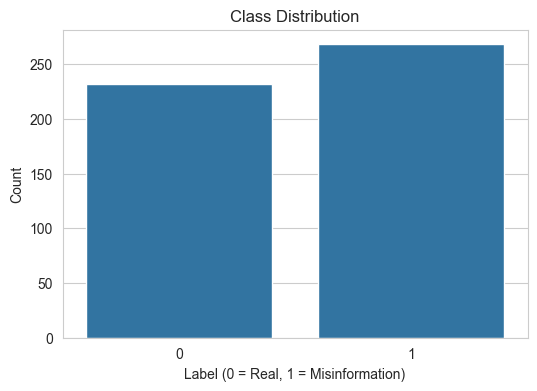

In [79]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['label'])
plt.title("Class Distribution")
plt.xlabel("Label (0 = Real, 1 = Misinformation)")
plt.ylabel("Count")
plt.show()

## Text Length Distribution

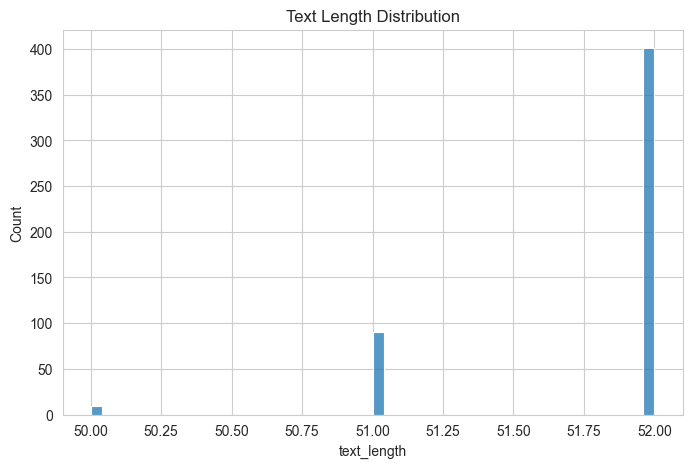

In [80]:
df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

## Word Count Analysis

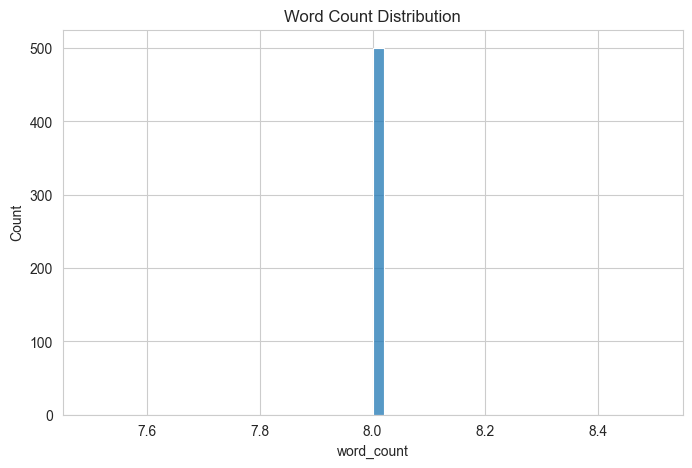

In [81]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

## Average Word Count by Label

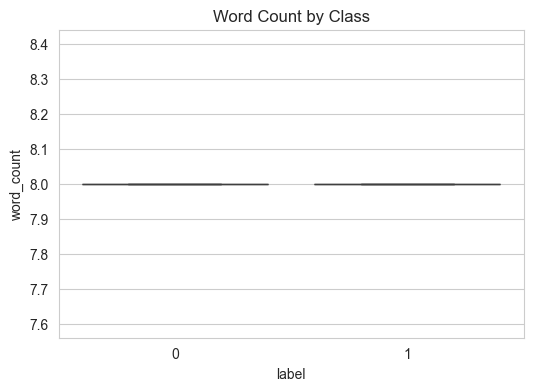

In [82]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['label'], y=df['word_count'])
plt.title("Word Count by Class")
plt.show()

## Train Test Split

In [83]:
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model
Baseline Machine Learning Model

In [84]:
# TF-IDF Vectorization

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [85]:
# Logistic Regression Model

lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [86]:
# Prediction
pred_lr = lr_model.predict(X_test_tfidf)
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.45      1.00      0.62        45
           1       0.00      0.00      0.00        55

    accuracy                           0.45       100
   macro avg       0.23      0.50      0.31       100
weighted avg       0.20      0.45      0.28       100



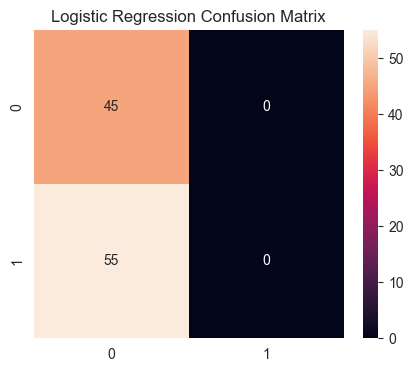

In [87]:
# Confusion Matrix

cm = confusion_matrix(y_test,pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Tokenization and Padding for Deep Learning

In [88]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# CNN Model

In [89]:
cnn_model = Sequential()

cnn_model.add(Embedding(10000,128,input_length=max_len))

cnn_model.add(Conv1D(128,5,activation='relu'))

cnn_model.add(GlobalMaxPooling1D())

cnn_model.add(Dense(64,activation='relu'))

cnn_model.add(Dense(1,activation='sigmoid'))

cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [90]:
# Train CNN Model

history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
10/10 [==============================] - 1s 33ms/step - loss: 0.6918 - accuracy: 0.5437 - val_loss: 0.7015 - val_accuracy: 0.4750
Epoch 2/20
10/10 [==============================] - 0s 15ms/step - loss: 0.6864 - accuracy: 0.5469 - val_loss: 0.7043 - val_accuracy: 0.4750
Epoch 3/20
10/10 [==============================] - 0s 16ms/step - loss: 0.6608 - accuracy: 0.7437 - val_loss: 0.6973 - val_accuracy: 0.4875
Epoch 4/20
10/10 [==============================] - 0s 15ms/step - loss: 0.5946 - accuracy: 0.7406 - val_loss: 0.6984 - val_accuracy: 0.4875
Epoch 5/20
10/10 [==============================] - 0s 15ms/step - loss: 0.4073 - accuracy: 1.0000 - val_loss: 0.7242 - val_accuracy: 0.4750
Epoch 6/20
10/10 [==============================] - 0s 15ms/step - loss: 0.1531 - accuracy: 1.0000 - val_loss: 0.7519 - val_accuracy: 0.4875
Epoch 7/20
10/10 [==============================] - 0s 15ms/step - loss: 0.0251 - accuracy: 1.0000 - val_loss: 0.7429 - val_accuracy: 0.4875
Epoch 8/20
10

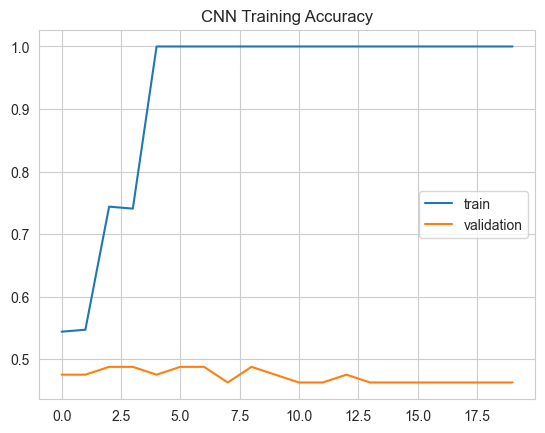

In [91]:
# CNN Accuracy Graph

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Training Accuracy")

plt.legend(['train','validation'])

plt.show()

# BiLSTM Model

In [92]:
bilstm_model = Sequential()

bilstm_model.add(Embedding(10000,128,input_length=max_len))

bilstm_model.add(Bidirectional(LSTM(64)))

bilstm_model.add(Dense(64,activation='relu'))

bilstm_model.add(Dense(1,activation='sigmoid'))

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [93]:
history_lstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
10/10 [==============================] - 5s 133ms/step - loss: 0.6922 - accuracy: 0.5469 - val_loss: 0.6986 - val_accuracy: 0.4750
Epoch 2/5
10/10 [==============================] - 0s 47ms/step - loss: 0.6887 - accuracy: 0.5469 - val_loss: 0.7009 - val_accuracy: 0.4750
Epoch 3/5
10/10 [==============================] - 0s 46ms/step - loss: 0.6872 - accuracy: 0.5469 - val_loss: 0.7046 - val_accuracy: 0.4750
Epoch 4/5
10/10 [==============================] - 0s 45ms/step - loss: 0.6859 - accuracy: 0.5469 - val_loss: 0.7065 - val_accuracy: 0.4750
Epoch 5/5
10/10 [==============================] - 0s 46ms/step - loss: 0.6721 - accuracy: 0.5469 - val_loss: 0.7000 - val_accuracy: 0.4750


## Model Performance Comparison

4/4 [==============================] - 0s 13ms/step - loss: 0.6884 - accuracy: 0.5500


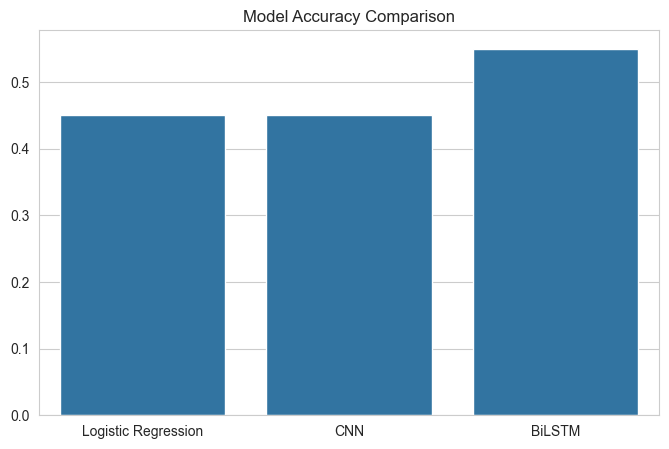

In [94]:
acc_lr = accuracy_score(y_test,pred_lr)

acc_cnn = cnn_model.evaluate(X_test_pad,y_test)[1]

acc_lstm = bilstm_model.evaluate(X_test_pad,y_test)[1]

models = ['Logistic Regression','CNN','BiLSTM']

accuracy = [acc_lr,acc_cnn,acc_lstm]

plt.figure(figsize=(8,5))

sns.barplot(x=models,y=accuracy)

plt.title("Model Accuracy Comparison")

plt.show()

In [95]:
results = pd.DataFrame({
    'Model':models,
    'Accuracy':accuracy
})

results

,Model,Accuracy
0,Logistic Regression,0.45
1,CNN,0.45
2,BiLSTM,0.55


In [96]:
bilstm_model.save("../models/ai_models/bilstm_ai_model.h5")

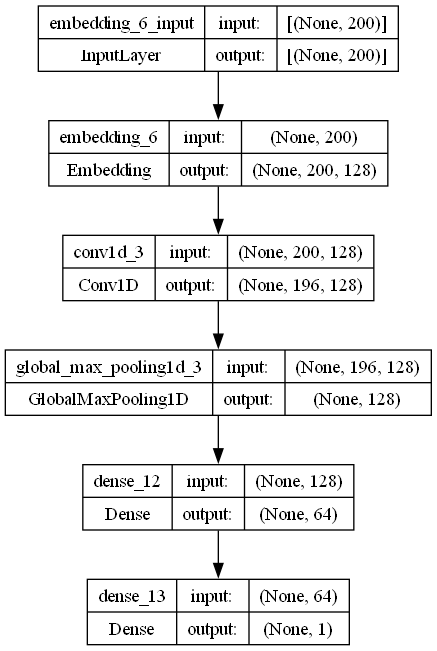

In [97]:
from tensorflow.keras.utils import plot_model

plot_model(cnn_model,
           to_file='cnn_architecture.png',
           show_shapes=True,
           show_layer_names=True)

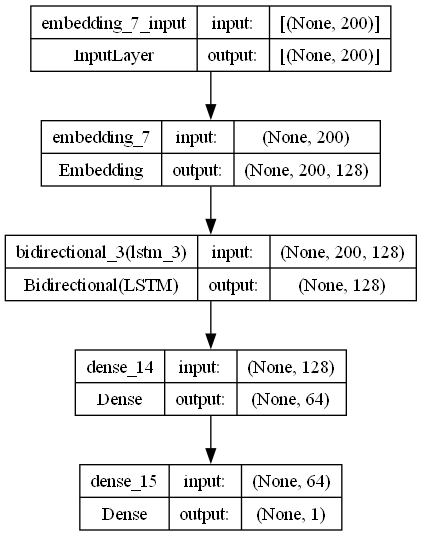

In [98]:
plot_model(bilstm_model,
           to_file='bilstm_architecture.png',
           show_shapes=True)